# 1. Executive Summary & Scope
A Philippine Statistics Authority (PSA) Labor and Employment dataset analysis (2016–2025).

### Research Questions
1. How has the size of the labor force changed from 2016 to 2025?
   - How has the number of Filipinos participating in the labor force changed from 2016 to 2025?
2. How has employment changed from 2016 to 2025?
   - How has the number of employed Filipinos changed from 2016 to 2025?
3. How has unemployment changed from 2016 to 2025?
   - How has unemployment changed from 2016 to 2025, particularly before, during, and after the COVID-19 period?
4. What happened during COVID-19?
   - How did the COVID-19 pandemic affect the Philippine labor market from 2019 to 2021, and how did the labor market recover afterward through 2025?
5. Is there a difference between males and females?
   - How do labor-force participation, employment, and unemployment differ between males and females from 2016 to 2025?
6. How has underemployment changed from 2016 to 2025?
   - How has underemployment changed from 2016 to 2025, and what does this suggest about employment conditions?

# 2. Environment & Data Setup

### Import Libraries and Setup

In [39]:
# pip install pandas numpy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Load Data

In [40]:
# Load DataFrame
data_path = 'data.csv'
labor_market = pd.read_csv(data_path, delimiter=';')

### Initial Inspection

In [41]:
print(f"Rows count: {labor_market.shape[0]}\nColumns count: {labor_market.shape[1]}")
labor_market.head()

Rows count: 10
Columns count: 17


,Year,Month,Total Population 15 Years Old and Over Both sexes,Total Population 15 Years Old and Over Male,Total Population 15 Years Old and Over Female,Persons in the Labor Force Both sexes,Persons in the Labor Force Male,Persons in the Labor Force Female,Employed Persons Both sexes,Employed Persons Male,Employed Persons Female,Unemployed Persons Both sexes,Unemployed Persons Male,Unemployed Persons Female,Underemployed Persons Both sexes,Underemployed Persons Male,Underemployed Persons Female
0,2016,Annual,68310.620,34184.066,34126.554,43360.939,26521.040,16839.899,40997.968,25034.788,15963.181,2362.970,1486.252,876.719,7512.544,5175.829,2336.715
1,2017,Annual,69890.686,35003.807,34886.879,42774.698,26667.402,16107.296,40333.992,25066.895,15267.097,2440.706,1600.507,840.199,6505.706,4465.670,2040.037
2,2018,Annual,71339.377,35781.919,35557.458,43459.905,26880.358,16579.547,41156.535,25424.309,15732.226,2303.371,1456.049,847.322,6734.331,4597.185,2137.146
3,2019,Annual,72143.459,36223.025,35920.435,44197.118,27104.740,17092.379,41938.013,25697.921,16240.092,2259.106,1406.819,852.287,5778.283,3928.176,1850.107
4,2020,Annual,73732.465,37029.448,36703.017,43878.159,27049.834,16828.325,39377.842,24179.071,15198.771,4500.318,2870.763,1629.554,6395.121,4327.980,2067.141


# 3. Data Quality & Preprocessing

### Data Types Check

In [42]:
labor_market.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 17 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   Year                                               10 non-null     int64  
 1   Month                                              10 non-null     object 
 2   Total Population 15 Years Old and Over Both sexes  10 non-null     float64
 3   Total Population 15 Years Old and Over Male        10 non-null     float64
 4   Total Population 15 Years Old and Over Female      10 non-null     float64
 5   Persons in the Labor Force Both sexes              10 non-null     float64
 6   Persons in the Labor Force Male                    10 non-null     float64
 7   Persons in the Labor Force Female                  10 non-null     float64
 8   Employed Persons Both sexes                        10 non-null     float64
 9   Employed Pers

### Missing Values Check

In [43]:
missing_percent = labor_market.isna().mean().sort_values(ascending=False)
print('---- Percentage of Missing Values (%) -----')
if missing_percent.sum():
    print(missing_percent[missing_percent > 0] * 100)
else:
    print('None')

---- Percentage of Missing Values (%) -----
None


### Duplicate Check

In [44]:
# Show number of duplicated rows
print(f"No. of entirely duplicated rows: {labor_market.duplicated().sum()}")

No. of entirely duplicated rows: 0


### Cardinality & Uniqueness Check

In [45]:
# Print the percentage of uniqueness of value in every column (100% means almost every row is distinct)
print('---- Unique Value Percentage (%) -----')
print((labor_market.nunique() / len(labor_market)) * 100)

---- Unique Value Percentage (%) -----
Year                                                 100.0
Month                                                 10.0
Total Population 15 Years Old and Over Both sexes    100.0
Total Population 15 Years Old and Over Male          100.0
Total Population 15 Years Old and Over Female        100.0
Persons in the Labor Force Both sexes                100.0
Persons in the Labor Force Male                      100.0
Persons in the Labor Force Female                    100.0
Employed Persons Both sexes                          100.0
Employed Persons Male                                100.0
Employed Persons Female                              100.0
Unemployed Persons Both sexes                        100.0
Unemployed Persons Male                              100.0
Unemployed Persons Female                            100.0
Underemployed Persons Both sexes                     100.0
Underemployed Persons Male                           100.0
Underemployed Per

### Feature Engineering

In [46]:
labor_market['Labor Force Participation Rate %'] = (labor_market['Persons in the Labor Force Both sexes'] / labor_market['Total Population 15 Years Old and Over Both sexes']) * 100
labor_market['Unemployment Rate %'] = (labor_market['Unemployed Persons Both sexes'] / labor_market['Persons in the Labor Force Both sexes']) * 100
labor_market['Underemployment Rate %'] = (labor_market['Underemployed Persons Both sexes'] / labor_market['Employed Persons Both sexes']) * 100

#### Total Market Rates

In [47]:
# The percentage of the working-age population (15 years old and over) that is economically active
# These are either employed or actively seeking work.
print(labor_market[['Year','Labor Force Participation Rate %']])

   Year  Labor Force Participation Rate %
0  2016                         63.476132
1  2017                         61.202287
2  2018                         60.919939
3  2019                         61.262821
4  2020                         59.509958
5  2021                         63.349872
6  2022                         64.701787
7  2023                         64.902518
8  2024                         64.425305
9  2025                         64.059575


In [48]:
#Unemployed: people in the active labor force who do not have a job but are available and looking for work.
#Underemployed: already employed workers who express the desire to have additional hours of work in their present job, an additional job, or a new job with longer working hours.
print(labor_market[['Year', 'Unemployment Rate %', 'Underemployment Rate %']])

   Year  Unemployment Rate %  Underemployment Rate %
0  2016             5.449536               18.324186
1  2017             5.705957               16.129586
2  2018             5.299991               16.362726
3  2019             5.111433               13.778152
4  2020            10.256397               16.240405
5  2021             7.787434               15.919765
6  2022             5.389858               14.238774
7  2023             4.353764               12.337530
8  2024             3.826072               11.912266
9  2025             4.189337               11.881209


# 4. Exploratory Data Analysis (EDA) & Trend Analysis

### Labor Force Dynamics

In [49]:
Persons_In_The_Labor_Force_Female_By_Year = labor_market[['Year', 'Persons in the Labor Force Female']]
Persons_In_The_Labor_Force_Male_By_Year = labor_market[['Year', 'Persons in the Labor Force Male']]
Persons_In_The_Labor_Force_Both_sexes = labor_market[['Year', 'Persons in the Labor Force Both sexes']]

#### Male Labor Force By Year

In [50]:
Persons_In_The_Labor_Force_Male_By_Year.info()
Persons_In_The_Labor_Force_Male_By_Year.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Year                             10 non-null     int64  
 1   Persons in the Labor Force Male  10 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 292.0 bytes


,Year,Persons in the Labor Force Male
0,2016,26521.040
1,2017,26667.402
2,2018,26880.358
3,2019,27104.740
4,2020,27049.834


#### Female Labor Force By Year

In [51]:
Persons_In_The_Labor_Force_Female_By_Year.info()
Persons_In_The_Labor_Force_Female_By_Year.head()
#Persons_In_The_Labor_Force_Female_By_Year.tail()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Year                               10 non-null     int64  
 1   Persons in the Labor Force Female  10 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 292.0 bytes


,Year,Persons in the Labor Force Female
0,2016,16839.899
1,2017,16107.296
2,2018,16579.547
3,2019,17092.379
4,2020,16828.325


#### Both Sexes Labor Force

In [52]:
Persons_In_The_Labor_Force_Both_sexes.info()
Persons_In_The_Labor_Force_Both_sexes.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Year                                   10 non-null     int64  
 1   Persons in the Labor Force Both sexes  10 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 292.0 bytes


,Year,Persons in the Labor Force Both sexes
0,2016,43360.939
1,2017,42774.698
2,2018,43459.905
3,2019,44197.118
4,2020,43878.159


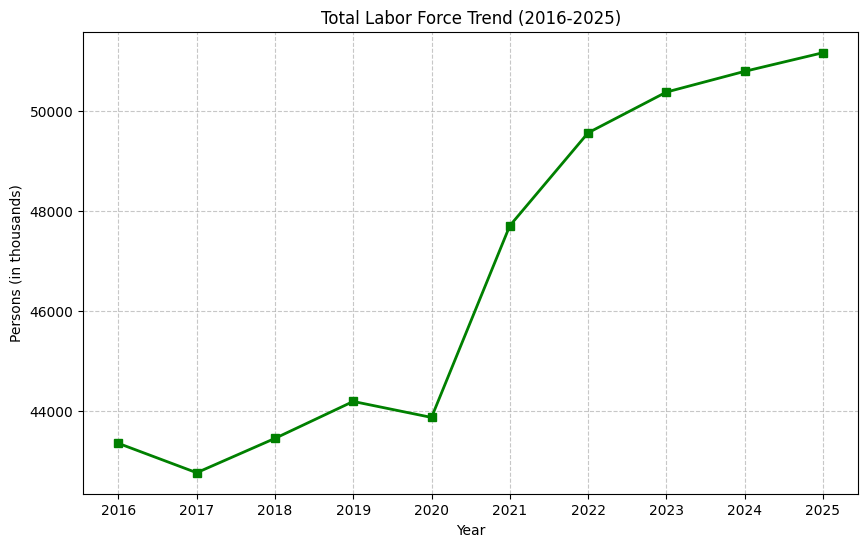

In [61]:
plt.figure(figsize=(10, 6))
plt.plot(labor_market['Year'], labor_market['Persons in the Labor Force Both sexes'], marker='s', color='green', linewidth=2)
plt.title('Total Labor Force Trend (2016-2025)')
plt.xlabel('Year')
plt.ylabel('Persons (in thousands)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(labor_market['Year'])
plt.show()

**Observation for RQ1:**
We can see a steady increase in the total labor force size. Despite the dip in participation rates seen during the pandemic year (2020), the absolute number of people in the labor force has continued to climb, surpassing 50 million by 2023.

### Employment & Underemployment Trends



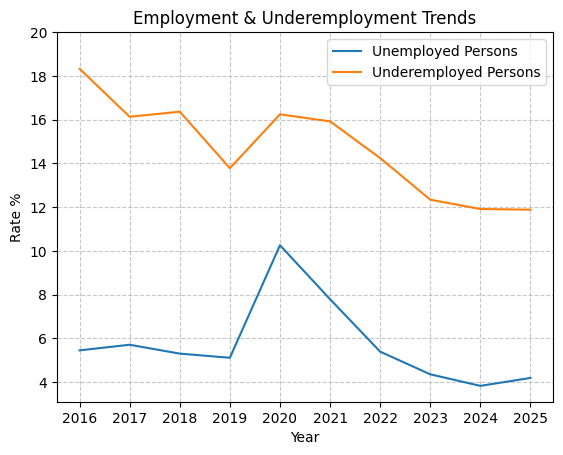

In [58]:
x = labor_market['Year']
y1 = labor_market['Unemployment Rate %']
y2 = labor_market['Underemployment Rate %']

plt.plot(x, y1, label = 'Unemployed Persons')
plt.plot(x, y2, label = 'Underemployed Persons')
plt.xlabel('Year')
plt.ylabel('Rate %')
plt.title('Employment & Underemployment Trends')
plt.xticks(np.arange(2016, 2026, 1))
plt.yticks(np.arange(4, 22, 2))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()


#### Interpretation w/ COVID-19 Impact & Recovery Analysis


*   Underemployment rate (Orange line) consistenly surpassed the unemployment across 10 years, sitting between ~18% and ~12%, whereas unemployment at ~10% and ~4%.  

*In the figure, we can see the drastic market shock caused by Covid-19:*
*   Unemployment drastically peaked from around ~5% in 2019 to ~10% in 2020.
*   Underemployment also surged back from around ~13% in 2019 to ~16% in 2020.

*We can also see how it recovered post-pandemic:*
*   Both metrics then consistently goes down after 2020.
*   By 2024 - 2025, Unemployment drops down lower than pre-pandemic levels to around ~4%.
*   The same can be seen with Underemployment, dropping to around ~12% in 2024 - 2025.







# 5. Demographic & Gender Disparity Analysis

### Gender-specific Rates

In [55]:
# Labor Force Participation Rate (LFPR)
labor_market['LFPR_Male_%'] = (labor_market['Persons in the Labor Force Male'] / labor_market['Total Population 15 Years Old and Over Male']) * 100
labor_market['LFPR_Female_%'] = (labor_market['Persons in the Labor Force Female'] / labor_market['Total Population 15 Years Old and Over Female']) * 100

### Male and Female in Labor Force Participation

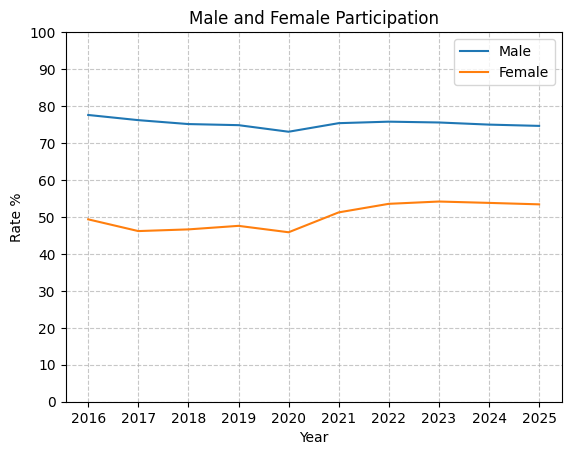

In [59]:
x = labor_market['Year']
y1 = labor_market['LFPR_Male_%']
y2 = labor_market['LFPR_Female_%']

plt.plot(x, y1, label = 'Male')
plt.plot(x, y2, label = 'Female')
plt.xlabel('Year')
plt.ylabel('Rate %')
plt.title('Male and Female Participation')
plt.xticks(np.arange(2016, 2026, 1))
plt.yticks(np.arange(0, 101, 10))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

- The large gap shows the socio-economic dynamic, where women historicallly undertake disproportionate share of unpaid domestic and care work, limiting formal labor force participation.

- The growth in female participation after 2020 points to structural economic shifts that presents changes such as expanded remote/hybrid work opportunities, more flexible informal/service sector jobs, or economic necessity driving secondary household earners into the active labor pool.

- In the figure, notice that male participation trend slightly downward overtime. Starting near ~78% in 2016, dipping to its lowest point around ~73% in 2020, and stabilizing near ~75% from 2021 through 2025.



### Gender Unemployment & Disparity


In [57]:
# Unemployment Rate for each gender
labor_market['Unemployment_Male_%'] = (labor_market['Unemployed Persons Male'] / labor_market['Persons in the Labor Force Male']) * 100
labor_market['Unemployment_Female_%'] = (labor_market['Unemployed Persons Female'] / labor_market['Persons in the Labor Force Female']) * 100

# Underemployment Rate for each gender
labor_market['Underemployment_Male_%'] = (labor_market['Underemployed Persons Male'] / labor_market['Employed Persons Male']) * 100
labor_market['Underemployment_Female_%'] = (labor_market['Underemployed Persons Female'] / labor_market['Employed Persons Female']) * 100

display(labor_market[['Year', 'Unemployment_Male_%', 'Unemployment_Female_%', 'Underemployment_Male_%', 'Underemployment_Female_%']])

,Year,Unemployment_Male_%,Unemployment_Female_%,Underemployment_Male_%,Underemployment_Female_%
0,2016,5.604049,5.206201,20.674547,14.638154
1,2017,6.001736,5.216263,17.815011,13.362311
2,2018,5.416777,5.110646,18.081848,13.584511
3,2019,5.190306,4.986357,15.285968,11.392220
4,2020,10.612867,9.683400,17.899695,13.600712
5,2021,7.477325,8.247598,17.713214,13.236174
6,2022,5.132259,5.757253,15.722440,12.108692
7,2023,4.154858,4.633512,13.775311,10.305228
8,2024,3.635309,4.093896,13.239300,10.040252
9,2025,4.073212,4.352953,13.318673,9.849948


# 6. Key Findings & Strategic Recommendations

### Economic Summary (Placeholder)
*Placeholder for economic synthesis and summary of findings.*

### Policy Implications (Placeholder)
*Placeholder for strategic policy recommendations and economic insights.*